<a href="https://colab.research.google.com/github/mbrinkl5/ECGR-4106---Introduction-to-Deep-Learning/blob/main/ECGR4106_HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import subprocess


In [2]:
# Automatically install nltk if it's missing to ensure error-free execution
try:
    import nltk
except ImportError:
    print("NLTK library not found. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
import time
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt




In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
#downloads dataset from google drive
dataset = pd.read_csv('/content/drive/MyDrive/vast_english_french.txt',
    sep='\t',
    header=None,
    names=['English', 'French']
)



In [7]:
train_df, val_df = train_test_split(
    dataset,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [8]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
def split_word(sentence):
    return sentence.lower().strip().split()

In [10]:
def build_vocab(sentences):
    vocab = {
        "PAD": PAD_token,
        "SOS": SOS_token,
        "EOS": EOS_token,
        "UNK": UNK_token
    }

    for sentence in sentences:
        for word in split_word(sentence):
            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

In [11]:
english_to_index = build_vocab(train_df["English"])
french_to_index = build_vocab(train_df["French"])

index_to_english = {i: word for word, i in english_to_index.items()}
index_to_french = {i: word for word, i in french_to_index.items()}

In [12]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, english_to_index, french_to_index):
        self.dataframe = dataframe
        self.english_to_index = english_to_index
        self.french_to_index = french_to_index

    def __len__(self):
        return len(self.dataframe)

    def sentence_to_tensor(self, sentence, vocab):
        tokens = split_word(sentence)

        indexes = [vocab.get(word, UNK_token) for word in tokens]
        indexes.append(EOS_token)

        return torch.tensor(indexes, dtype=torch.long, device=device)

    def __getitem__(self, idx):
        english_sentence = self.dataframe.iloc[idx]["English"]
        french_sentence = self.dataframe.iloc[idx]["French"]

        input_tensor = self.sentence_to_tensor(
            english_sentence,
            self.english_to_index
        )

        target_tensor = self.sentence_to_tensor(
            french_sentence,
            self.french_to_index
        )

        return input_tensor, target_tensor

In [13]:

train_dataset = TranslationDataset(train_df, english_to_index, french_to_index)
val_dataset = TranslationDataset(val_df, english_to_index, french_to_index)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)


In [14]:
MAX_LENGTH = max(len(split_word(sentence)) for sentence in train_df["English"]) + 1

# Problem 1 - Baseline Encoder-Decoder Architecture

In [16]:

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)
        return output, hidden_state

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.dropout_p = dropout_p
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(self.dropout_p)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        embedded = self.dropout(embedded)
        output, hidden_state = self.gru(embedded, hidden_state)
        output = self.softmax(self.out(output[0]))
        return output, hidden_state

In [17]:
input_size = len(english_to_index)
hidden_size = 256
output_size = len(french_to_index)

encoder = Encoder(input_size, hidden_size).to(device)
decoder = Decoder(hidden_size, output_size, dropout_p=0.1).to(device)

In [18]:
#  Optimization parameters
learning_rate = 0.001

encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()



In [19]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt

def train(input_tensor, target_tensor, encoder, decoder,
          encoder_optimizer, decoder_optimizer, criterion):

    encoder.train()
    decoder.train()

    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    loss = 0

    # Encode English sentence
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei].unsqueeze(0),
            encoder_hidden
        )

    # Decoder starts with SOS
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    # Teacher forcing: use real previous French word
    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(
            decoder_input,
            decoder_hidden
        )

        loss += criterion(
            decoder_output,
            target_tensor[di].unsqueeze(0)
        )

        decoder_input = target_tensor[di].view(1, 1)

        if target_tensor[di].item() == EOS_token:
            break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [20]:
def validate_loss(input_tensor, target_tensor, encoder, decoder, criterion):

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_hidden = encoder.initHidden()

        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei].unsqueeze(0),
                encoder_hidden
            )

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input,
                decoder_hidden
            )

            loss += criterion(
                decoder_output,
                target_tensor[di].unsqueeze(0)
            )

            decoder_input = target_tensor[di].view(1, 1)

            if target_tensor[di].item() == EOS_token:
                break

    return loss.item() / target_length

In [21]:
n_epochs = 50

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_encoder_state = None
best_decoder_state = None

print("Starting Training...")

for epoch in range(n_epochs):
    total_train_loss = 0
    total_val_loss = 0

    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = train(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            encoder_optimizer,
            decoder_optimizer,
            criterion
        )

        total_train_loss += loss

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = validate_loss(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            criterion
        )

        total_val_loss += loss

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Checkpointing:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_encoder_state = encoder.state_dict()
        best_decoder_state = decoder.state_dict()
        print(f"    (New best model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f})")

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("\nLoading best model checkpoint for evaluation...")
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    decoder.load_state_dict(best_decoder_state)
    print(f"Best model (with validation loss: {best_val_loss:.4f}) loaded successfully.")
else:
    print("No best model found. Using the model from the last epoch.")

Starting Training...
    (New best model saved at epoch 1 with validation loss: 6.3768)
Epoch 00 | Train Loss: 6.6839 | Val Loss: 6.3768
    (New best model saved at epoch 2 with validation loss: 5.6681)
    (New best model saved at epoch 3 with validation loss: 5.3632)
    (New best model saved at epoch 4 with validation loss: 5.2390)
    (New best model saved at epoch 5 with validation loss: 5.1537)
    (New best model saved at epoch 6 with validation loss: 5.1151)
Epoch 05 | Train Loss: 4.8081 | Val Loss: 5.1151
    (New best model saved at epoch 7 with validation loss: 5.0655)
    (New best model saved at epoch 8 with validation loss: 4.9881)
    (New best model saved at epoch 9 with validation loss: 4.9422)
    (New best model saved at epoch 10 with validation loss: 4.8974)
    (New best model saved at epoch 11 with validation loss: 4.8703)
Epoch 10 | Train Loss: 4.2664 | Val Loss: 4.8703
    (New best model saved at epoch 12 with validation loss: 4.8287)
    (New best model saved

In [22]:
def estimate_baseline_flops(input_tensor, target_tensor, hidden_size, output_vocab_size):
    input_len = input_tensor.size(0)
    target_len = target_tensor.size(0)

    # Encoder FLOPs
    encoder_flops = input_len * (12 * hidden_size * hidden_size)

    # Decoder FLOPs
    # Each decoder step:
    decoder_flops = target_len * (12 * hidden_size * hidden_size + hidden_size * output_vocab_size)

    return encoder_flops + decoder_flops

In [23]:
def average_baseline_flops(val_loader, hidden_size, output_vocab_size):
    total_flops = 0
    total_samples = 0

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0]
        target_tensor = target_tensor[0]

        total_flops += estimate_baseline_flops(
            input_tensor,
            target_tensor,
            hidden_size,
            output_vocab_size
        )

        total_samples += 1

    return total_flops / total_samples

In [24]:
baseline_params = count_parameters(encoder) + count_parameters(decoder)
baseline_flops = average_baseline_flops(val_loader, hidden_size, output_size)


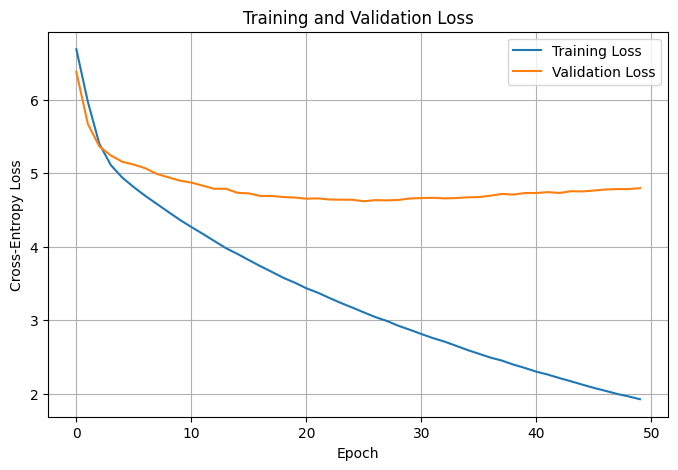

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
def evaluate_inference_speed_baseline(encoder, decoder, val_loader, max_length):
    start_time = time.time()
    num_batches = 0

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for input_tensor, target_tensor in val_loader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(max_length):
                decoder_output, decoder_hidden = decoder(
                    decoder_input,
                    decoder_hidden
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()
            num_batches += 1

    end_time = time.time()
    total_inference_time_ms = (end_time - start_time) * 1000
    infer_ms_per_batch = total_inference_time_ms / num_batches

    return infer_ms_per_batch

In [27]:
baseline_infer_ms_per_batch = evaluate_inference_speed_baseline(encoder, decoder, val_loader, MAX_LENGTH)

print(f"Baseline Parameters: {baseline_params:,}")
print(f"Baseline Avg FLOPs per validation sample: {baseline_flops:,.0f}")
print(f"Baseline Inference Speed per batch (ms): {baseline_infer_ms_per_batch:.2f}")

Baseline Parameters: 1,527,777
Baseline Avg FLOPs per validation sample: 13,484,336
Baseline Inference Speed per batch (ms): 6.67


In [28]:
def indexes_to_words(indexes, index_to_word):
    words = []

    for idx in indexes:
        if idx in [SOS_token, EOS_token, PAD_token]:
            continue
        words.append(index_to_word.get(idx, "UNK"))

    return words

In [29]:
def evaluate_validation_metrics(encoder, decoder, val_loader, max_length=30, n_examples=5):

    encoder.eval()
    decoder.eval()

    correct_exact_matches = 0
    total_bleu_score = 0.0
    total_samples = 0

    smoothing = SmoothingFunction().method1

    print("\n--- Validation Examples ---")

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(max_length):
                decoder_output, decoder_hidden = decoder(
                    decoder_input,
                    decoder_hidden
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()

            target_indices = target_tensor.cpu().tolist()
            input_indices = input_tensor.cpu().tolist()

            input_words = indexes_to_words(input_indices, index_to_english)
            target_words = indexes_to_words(target_indices, index_to_french)
            predicted_words = indexes_to_words(predicted_indices, index_to_french)

            if predicted_words == target_words:
                correct_exact_matches += 1

            bleu = sentence_bleu(
                [target_words],
                predicted_words,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoothing
            )

            total_bleu_score += bleu
            total_samples += 1

            if i < n_examples:
                print(f"Input:     {' '.join(input_words)}")
                print(f"Target:    {' '.join(target_words)}")
                print(f"Predicted: {' '.join(predicted_words)}")
                print(f"BLEU-4:    {bleu:.4f}")
                print("-" * 60)

    exact_accuracy = correct_exact_matches / total_samples
    avg_bleu = total_bleu_score / total_samples

    print("\nFinal Validation Metrics:")
    print(f"Traditional Exact-Match Accuracy: {exact_accuracy * 100:.2f}%")
    print(f"Average Validation BLEU-4 Score: {avg_bleu:.4f}")

    return exact_accuracy, avg_bleu

In [30]:
exact_accuracy, avg_bleu = evaluate_validation_metrics(
    encoder,
    decoder,
    val_loader
)


--- Validation Examples ---
Input:     she won a tennis match
Target:    elle a gagné un match de tennis
Predicted: elle a acheté un grand voyage en bois
BLEU-4:    0.0650
------------------------------------------------------------
Input:     the organic market opens at UNK on UNK
Target:    le marché biologique ouvre à UNK le UNK
Predicted: ils ont construit une grande maison
BLEU-4:    0.0000
------------------------------------------------------------
Input:     we watch a movie together
Target:    nous regardons un film ensemble
Predicted: nous avons visité le monument pendant l'été
BLEU-4:    0.0330
------------------------------------------------------------
Input:     the bread at this bakery is always UNK
Target:    le pain de cette boulangerie est toujours UNK
Predicted: le pain est très sucré
BLEU-4:    0.0690
------------------------------------------------------------
Input:     we dance at the wedding
Target:    nous UNK au mariage
Predicted: nous avons visité le monumen

# Problem 2: Sequence-to-Sequence with Attention

In [31]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)
        return output, hidden_state

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class AttnDecoder(nn.Module):

    def __init__(self, hidden_size, output_size, max_length, dropout_p=0.1):
        super(AttnDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = MAX_LENGTH

        self.embedding = nn.Embedding(self.output_size, self.hidden_size)
        # Attention weights
        self.attn = nn.Linear(self.hidden_size * 2, self.max_length)
        # Combine embedded input and context vector
        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        # Calculate attention weights
        attn_weights = torch.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)
        # Apply attention weights to encoder outputs to get context
        attn_applied = torch.bmm(attn_weights.unsqueeze(0),
                                 encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = torch.relu(output)
        output, hidden = self.gru(output, hidden)

        output = torch.log_softmax(self.out(output[0]), dim=1)
        return output, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

In [32]:
input_size = len(english_to_index)
hidden_size = 256
output_size = len(french_to_index)

encoder = Encoder(input_size, hidden_size).to(device)
decoder = AttnDecoder(hidden_size, output_size, MAX_LENGTH).to(device)

In [33]:
#  Optimization parameters
learning_rate = 0.001

encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()



In [34]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt

def train(input_tensor, target_tensor, encoder, decoder,
          encoder_optimizer, decoder_optimizer, criterion):

    encoder.train()
    decoder.train()

    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    loss = 0

    # Prepare tensor to store encoder outputs, sized to MAX_LENGTH
    encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

    # Encode English sentence
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei].unsqueeze(0),
            encoder_hidden
        )
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    # Teacher forcing: use real previous French word
    for di in range(target_length):
        decoder_output, decoder_hidden, _ = decoder(
            decoder_input,
            decoder_hidden,
            encoder_outputs
        )

        loss += criterion(
            decoder_output,
            target_tensor[di].unsqueeze(0)
        )

        decoder_input = target_tensor[di].view(1, 1)

        if target_tensor[di].item() == EOS_token:
            break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [35]:
def validate_loss(input_tensor, target_tensor, encoder, decoder, criterion):

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_hidden = encoder.initHidden()

        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0

        # Prepare tensor to store encoder outputs, sized to MAX_LENGTH
        encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei].unsqueeze(0),
                encoder_hidden
            )
            encoder_outputs[ei] = encoder_output[0, 0]

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        for di in range(target_length):
            decoder_output, decoder_hidden, _ = decoder(
                decoder_input,
                decoder_hidden,
                encoder_outputs
            )

            loss += criterion(
                decoder_output,
                target_tensor[di].unsqueeze(0)
            )

            decoder_input = target_tensor[di].view(1, 1)

            if target_tensor[di].item() == EOS_token:
                break

    return loss.item() / target_length

In [36]:
n_epochs = 50

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_encoder_state = None
best_decoder_state = None

print("Starting Training...")

for epoch in range(n_epochs):
    total_train_loss = 0
    total_val_loss = 0

    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = train(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            encoder_optimizer,
            decoder_optimizer,
            criterion
        )

        total_train_loss += loss

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = validate_loss(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            criterion
        )

        total_val_loss += loss

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Checkpointing:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_encoder_state = encoder.state_dict()
        best_decoder_state = decoder.state_dict()
        print(f"    (New best model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f})")

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("\nLoading best model checkpoint for evaluation...")
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    decoder.load_state_dict(best_decoder_state)
    print(f"Best model (with validation loss: {best_val_loss:.4f}) loaded successfully.")
else:
    print("No best model found. Using the model from the last epoch.")

Starting Training...
    (New best model saved at epoch 1 with validation loss: 5.9182)
Epoch 00 | Train Loss: 6.4218 | Val Loss: 5.9182
    (New best model saved at epoch 2 with validation loss: 5.4648)
    (New best model saved at epoch 3 with validation loss: 5.3588)
    (New best model saved at epoch 4 with validation loss: 5.3143)
    (New best model saved at epoch 5 with validation loss: 5.2438)
    (New best model saved at epoch 6 with validation loss: 5.2161)
Epoch 05 | Train Loss: 5.0004 | Val Loss: 5.2161
    (New best model saved at epoch 7 with validation loss: 5.1923)
    (New best model saved at epoch 8 with validation loss: 5.1205)
    (New best model saved at epoch 9 with validation loss: 5.0824)
    (New best model saved at epoch 10 with validation loss: 5.0196)
    (New best model saved at epoch 11 with validation loss: 4.9801)
Epoch 10 | Train Loss: 4.6006 | Val Loss: 4.9801
    (New best model saved at epoch 12 with validation loss: 4.9233)
    (New best model saved

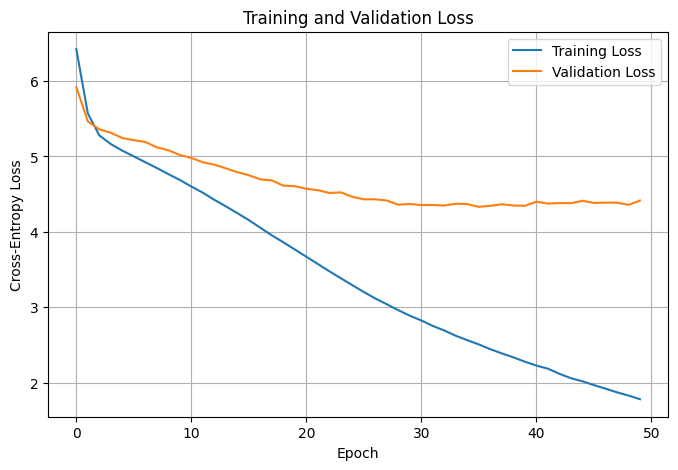

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
def estimate_attn_flops(input_tensor, target_tensor, hidden_size, max_length):
    input_len = input_tensor.size(0)
    target_len = target_tensor.size(0)

    # Encoder FLOPs (simplified for GRU)
    encoder_flops = input_len * (12 * hidden_size * hidden_size)


    attn_layer_flops = (hidden_size * max_length) + (2 * hidden_size * hidden_size) + (hidden_size * len(index_to_english))
    decoder_flops = target_len * (12 * hidden_size * hidden_size + attn_layer_flops)

    return encoder_flops + decoder_flops

In [39]:
def average_attn_flops(val_loader, hidden_size, max_length):
    total_flops = 0
    total_samples = 0

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0]
        target_tensor = target_tensor[0]

        total_flops += estimate_attn_flops(
            input_tensor,
            target_tensor,
            hidden_size,
            max_length
        )

        total_samples += 1

    return total_flops / total_samples

In [40]:
def evaluate_inference_speed(encoder, decoder, val_loader):
    start_time = time.time()
    num_batches = 0

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for input_tensor, target_tensor in val_loader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()
            encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(MAX_LENGTH):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()
            num_batches += 1

    end_time = time.time()
    total_inference_time_ms = (end_time - start_time) * 1000
    infer_ms_per_batch = total_inference_time_ms / num_batches

    return infer_ms_per_batch

In [41]:
attn_params = count_parameters(encoder) + count_parameters(decoder)
attn_flops = average_attn_flops(val_loader, hidden_size, MAX_LENGTH)
infer_ms_per_batch = evaluate_inference_speed(encoder, decoder, val_loader)

print(f"Attention Model Parameters: {attn_params:,}")
print(f"Attention Model Avg FLOPs per validation sample: {attn_flops:,.0f}")
print(f"Attention Model Inference Speed per batch (ms): {infer_ms_per_batch:.2f}")

Attention Model Parameters: 1,664,748
Attention Model Avg FLOPs per validation sample: 14,301,839
Attention Model Inference Speed per batch (ms): 6.41


In [42]:
def indexes_to_words(indexes, index_to_word):
    words = []

    for idx in indexes:
        if idx in [SOS_token, EOS_token, PAD_token]:
            continue
        words.append(index_to_word.get(idx, "UNK"))

    return words

In [43]:
def evaluate_validation_metrics(encoder, decoder, val_loader, max_length=30, n_examples=5):

    encoder.eval()
    decoder.eval()

    correct_exact_matches = 0
    total_bleu_score = 0.0
    total_samples = 0

    smoothing = SmoothingFunction().method1

    print("\n--- Validation Examples ---")

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()

            # Prepare tensor to store encoder outputs, sized to MAX_LENGTH
            encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(max_length):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()

            target_indices = target_tensor.cpu().tolist()
            input_indices = input_tensor.cpu().tolist()

            input_words = indexes_to_words(input_indices, index_to_english)
            target_words = indexes_to_words(target_indices, index_to_french)
            predicted_words = indexes_to_words(predicted_indices, index_to_french)

            if predicted_words == target_words:
                correct_exact_matches += 1

            bleu = sentence_bleu(
                [target_words],
                predicted_words,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoothing
            )

            total_bleu_score += bleu
            total_samples += 1

            if i < n_examples:
                print(f"Input:     {' '.join(input_words)}")
                print(f"Target:    {' '.join(target_words)}")
                print(f"Predicted: {' '.join(predicted_words)}")
                print(f"BLEU-4:    {bleu:.4f}")
                print("-" * 60)

    exact_accuracy = correct_exact_matches / total_samples
    avg_bleu = total_bleu_score / total_samples

    print("\nFinal Validation Metrics:")
    print(f"Traditional Exact-Match Accuracy: {exact_accuracy * 100:.2f}%")
    print(f"Average Validation BLEU-4 Score: {avg_bleu:.4f}")

    return exact_accuracy, avg_bleu

In [46]:
exact_accuracy, avg_bleu = evaluate_validation_metrics(
    encoder,
    decoder,
    val_loader
)


--- Validation Examples ---
Input:     she won a tennis match
Target:    elle a gagné un match de tennis
Predicted: elle a une belle bague
BLEU-4:    0.0762
------------------------------------------------------------
Input:     the organic market opens at UNK on UNK
Target:    le marché biologique ouvre à UNK le UNK
Predicted: le pain frais sent merveilleusement bon
BLEU-4:    0.0293
------------------------------------------------------------
Input:     we watch a movie together
Target:    nous regardons un film ensemble
Predicted: nous avons célébré un grand en
BLEU-4:    0.0485
------------------------------------------------------------
Input:     the bread at this bakery is always UNK
Target:    le pain de cette boulangerie est toujours UNK
Predicted: le pain frais est trop à lire
BLEU-4:    0.0670
------------------------------------------------------------
Input:     we dance at the wedding
Target:    nous UNK au mariage
Predicted: nous avons visité le monument historique
BLEU

In [85]:
def evaluate_and_show_attention(encoder, decoder, sentence, max_length=MAX_LENGTH):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        input_tensor = train_dataset.sentence_to_tensor(sentence, french_to_index)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.initHidden()

        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei].unsqueeze(0),
                encoder_hidden
            )
            encoder_outputs[ei] = encoder_output[0, 0]

        decoder_input = torch.tensor([[SOS_token]], device=device)  # SOS
        decoder_hidden = encoder_hidden

        decoded_words = []
        attentions = torch.zeros(max_length, max_length)

        for di in range(max_length):
            decoder_output, decoder_hidden, attn_weights = decoder(
                decoder_input,
                decoder_hidden,
                encoder_outputs
            )
            attentions[di] = attn_weights.data
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(index_to_english[topi.item()])

            decoder_input = topi.squeeze().detach()

        return decoded_words, attentions[:di + 1, :input_length]

def show_attention_heatmap(input_sentence, output_words, attentions):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel('Input French Sentence')
    plt.ylabel('Predicted English Sentence')
    plt.title('Attention Weights (French to English)')
    plt.show()




--- Attention Visualization Examples ---

Input French: elle a gagné un match de tennis
Predicted English: she paints her lost a new pair of the ocean <EOS>


/tmp/ipykernel_14107/4048251015.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/4048251015.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


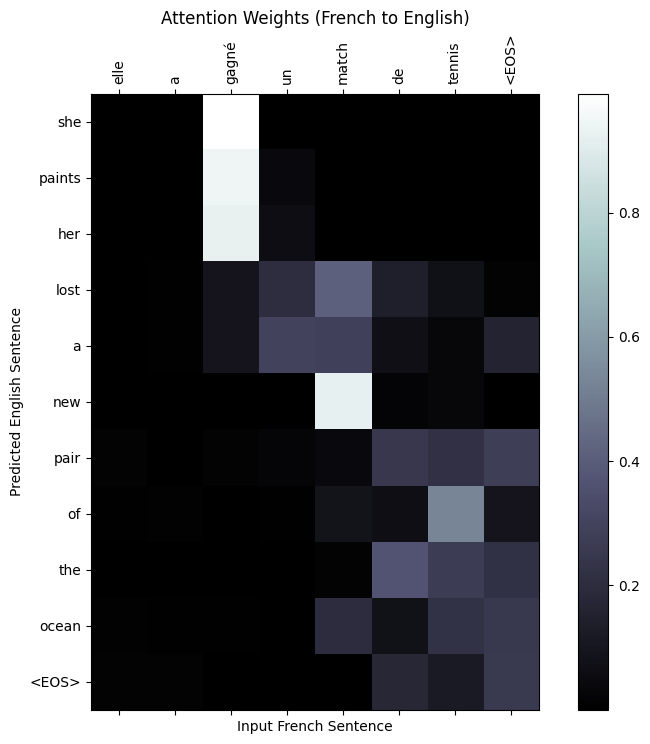


Input French: le marché biologique ouvre à UNK le UNK
Predicted English: the birds are going to the party <EOS>


/tmp/ipykernel_14107/4048251015.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/4048251015.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


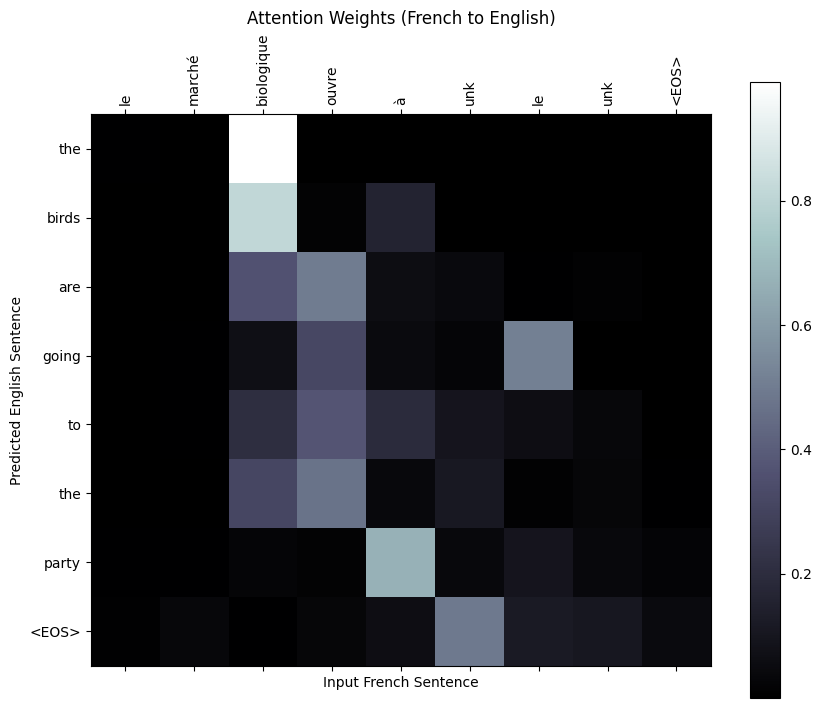


Input French: nous regardons un film ensemble
Predicted English: we are planning a new pair of the ocean <EOS>


/tmp/ipykernel_14107/4048251015.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/4048251015.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


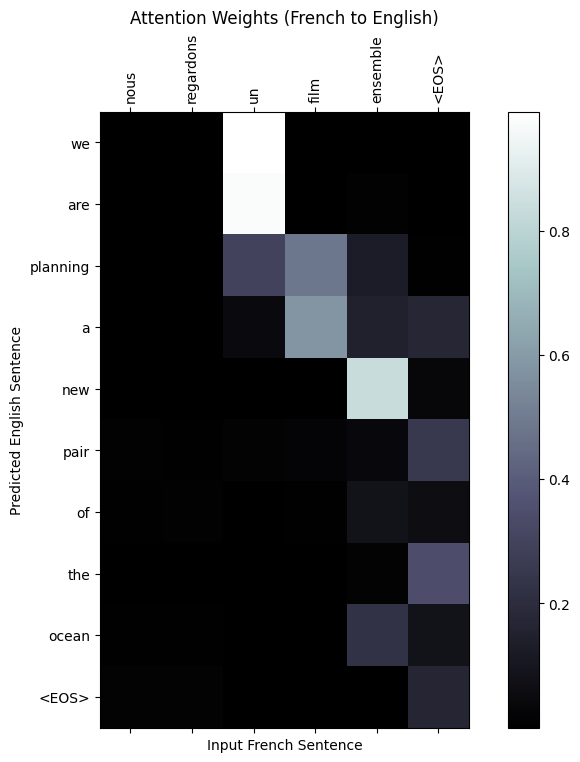


Input French: le pain de cette boulangerie est toujours UNK
Predicted English: the birds are building a new pair of the ocean <EOS>


/tmp/ipykernel_14107/4048251015.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/4048251015.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


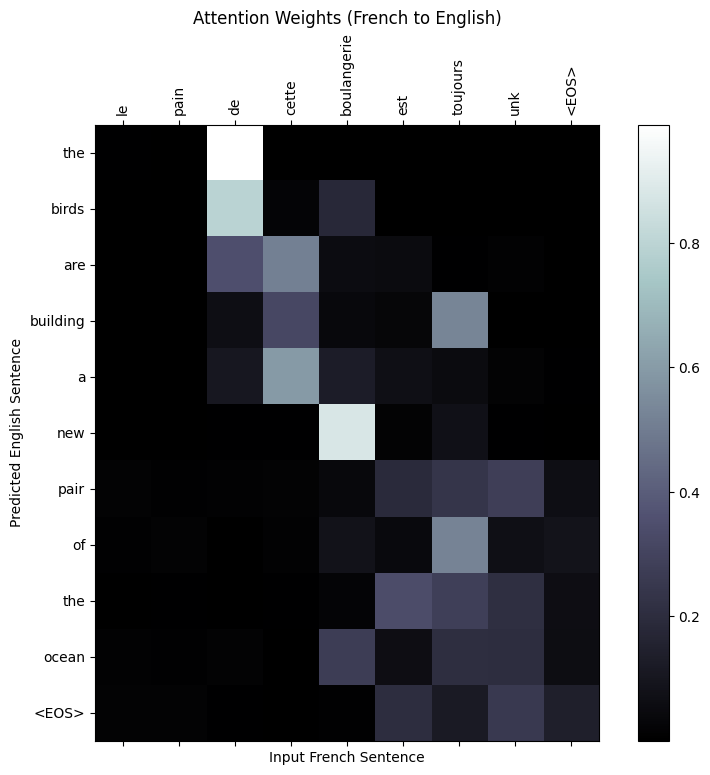


Input French: nous UNK au mariage
Predicted English: we are going to the beach <EOS>


/tmp/ipykernel_14107/4048251015.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/4048251015.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


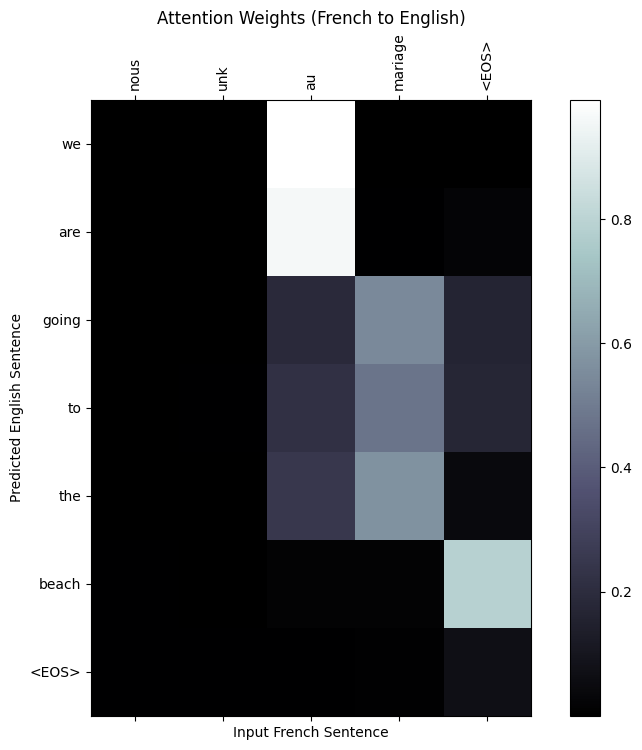

In [86]:
import matplotlib.ticker as ticker

# Get a few examples from the validation loader
num_examples_to_show = 5

print("\n--- Attention Visualization Examples ---")
for i, (input_tensor, target_tensor) in enumerate(val_loader):
    if i >= num_examples_to_show:
        break

    # The input to this model is French (french_to_index)
    input_indices = input_tensor[0].cpu().tolist()
    input_words = indexes_to_words(input_indices, index_to_french)
    input_sentence_fr = ' '.join(input_words)

    # Generate and show attention for the French input sentence
    output_words, attentions = evaluate_and_show_attention(encoder, decoder, input_sentence_fr)

    print(f"\nInput French: {input_sentence_fr}")
    print(f"Predicted English: {' '.join(output_words)}")
    show_attention_heatmap(input_sentence_fr, output_words, attentions)

# **Problem** **3**: **Reversing** **the** **Language** **Direction**

# **Baseline** **GRU**

In [48]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, english_to_index, french_to_index):
        self.dataframe = dataframe
        self.english_to_index = english_to_index
        self.french_to_index = french_to_index

    def __len__(self):
        return len(self.dataframe)

    def sentence_to_tensor(self, sentence, vocab):
        tokens = split_word(sentence)

        indexes = [vocab.get(word, UNK_token) for word in tokens]
        indexes.append(EOS_token)

        return torch.tensor(indexes, dtype=torch.long, device=device)

    def __getitem__(self, idx):
       french_sentence = self.dataframe.iloc[idx]["French"]
       english_sentence = self.dataframe.iloc[idx]["English"]

       input_tensor = self.sentence_to_tensor(
            french_sentence,
            self.french_to_index
        )

       target_tensor = self.sentence_to_tensor(
            english_sentence,
            self.english_to_index
        )

       return input_tensor, target_tensor

In [49]:

train_dataset = TranslationDataset(train_df, english_to_index, french_to_index)
val_dataset = TranslationDataset(val_df, english_to_index, french_to_index)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)


In [50]:
MAX_LENGTH = max(len(split_word(sentence)) for sentence in train_df["French"]) + 1

In [51]:

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)
        return output, hidden_state

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.dropout_p = dropout_p
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(self.dropout_p)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        embedded = self.dropout(embedded)
        output, hidden_state = self.gru(embedded, hidden_state)
        output = self.softmax(self.out(output[0]))
        return output, hidden_state

In [52]:
input_size = len(french_to_index)
hidden_size = 256
output_size = len(english_to_index)

encoder = Encoder(input_size, hidden_size).to(device)
decoder = Decoder(hidden_size, output_size, dropout_p=0.1).to(device)

In [53]:
#  Optimization parameters
learning_rate = 0.001

encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()



In [54]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt

def train(input_tensor, target_tensor, encoder, decoder,
          encoder_optimizer, decoder_optimizer, criterion):

    encoder.train()
    decoder.train()

    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    loss = 0

    # Encode English sentence
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei].unsqueeze(0),
            encoder_hidden
        )

    # Decoder starts with SOS
    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    # Teacher forcing: use real previous French word
    for di in range(target_length):
        decoder_output, decoder_hidden = decoder(
            decoder_input,
            decoder_hidden
        )

        loss += criterion(
            decoder_output,
            target_tensor[di].unsqueeze(0)
        )

        decoder_input = target_tensor[di].view(1, 1)

        if target_tensor[di].item() == EOS_token:
            break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [55]:
def validate_loss(input_tensor, target_tensor, encoder, decoder, criterion):

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_hidden = encoder.initHidden()

        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei].unsqueeze(0),
                encoder_hidden
            )

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input,
                decoder_hidden
            )

            loss += criterion(
                decoder_output,
                target_tensor[di].unsqueeze(0)
            )

            decoder_input = target_tensor[di].view(1, 1)

            if target_tensor[di].item() == EOS_token:
                break

    return loss.item() / target_length

In [56]:
n_epochs = 50

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_encoder_state = None
best_decoder_state = None

print("Starting Training...")

for epoch in range(n_epochs):
    total_train_loss = 0
    total_val_loss = 0

    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = train(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            encoder_optimizer,
            decoder_optimizer,
            criterion
        )

        total_train_loss += loss

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = validate_loss(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            criterion
        )

        total_val_loss += loss

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Checkpointing:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_encoder_state = encoder.state_dict()
        best_decoder_state = decoder.state_dict()
        print(f"    (New best model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f})")

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("\nLoading best model checkpoint for evaluation...")
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    decoder.load_state_dict(best_decoder_state)
    print(f"Best model (with validation loss: {best_val_loss:.4f}) loaded successfully.")
else:
    print("No best model found. Using the model from the last epoch.")

Starting Training...
    (New best model saved at epoch 1 with validation loss: 5.9250)
Epoch 00 | Train Loss: 6.4245 | Val Loss: 5.9250
    (New best model saved at epoch 2 with validation loss: 5.2590)
    (New best model saved at epoch 3 with validation loss: 5.0113)
    (New best model saved at epoch 4 with validation loss: 4.8987)
    (New best model saved at epoch 5 with validation loss: 4.8321)
    (New best model saved at epoch 6 with validation loss: 4.7686)
Epoch 05 | Train Loss: 4.5362 | Val Loss: 4.7686
    (New best model saved at epoch 7 with validation loss: 4.7239)
    (New best model saved at epoch 8 with validation loss: 4.6851)
    (New best model saved at epoch 9 with validation loss: 4.6502)
    (New best model saved at epoch 10 with validation loss: 4.6160)
    (New best model saved at epoch 11 with validation loss: 4.5919)
Epoch 10 | Train Loss: 3.9998 | Val Loss: 4.5919
    (New best model saved at epoch 12 with validation loss: 4.5697)
    (New best model saved

In [57]:
def estimate_baseline_flops(input_tensor, target_tensor, hidden_size, output_vocab_size):
    input_len = input_tensor.size(0)
    target_len = target_tensor.size(0)


    encoder_flops = input_len * (12 * hidden_size * hidden_size)


    decoder_flops = target_len * (12 * hidden_size * hidden_size + hidden_size * output_vocab_size)

    return encoder_flops + decoder_flops

In [58]:
def average_baseline_flops(val_loader, hidden_size, output_vocab_size):
    total_flops = 0
    total_samples = 0

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0]
        target_tensor = target_tensor[0]

        total_flops += estimate_baseline_flops(
            input_tensor,
            target_tensor,
            hidden_size,
            output_vocab_size
        )

        total_samples += 1

    return total_flops / total_samples

In [59]:
baseline_params = count_parameters(encoder) + count_parameters(decoder)
baseline_flops = average_baseline_flops(val_loader, hidden_size, output_size)


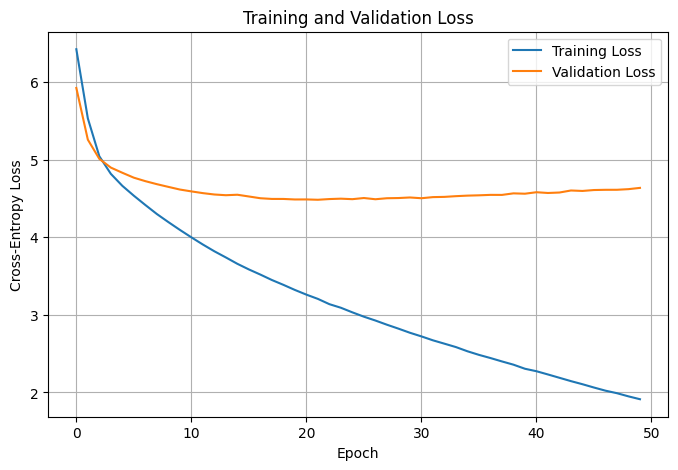

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
def evaluate_inference_speed_baseline(encoder, decoder, val_loader, max_length):
    start_time = time.time()
    num_batches = 0

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for input_tensor, target_tensor in val_loader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(max_length):
                decoder_output, decoder_hidden = decoder(
                    decoder_input,
                    decoder_hidden
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()
            num_batches += 1

    end_time = time.time()
    total_inference_time_ms = (end_time - start_time) * 1000
    infer_ms_per_batch = total_inference_time_ms / num_batches

    return infer_ms_per_batch

In [62]:
baseline_infer_ms_per_batch = evaluate_inference_speed_baseline(encoder, decoder, val_loader, MAX_LENGTH)

print(f"Baseline Parameters: {baseline_params:,}")
print(f"Baseline Avg FLOPs per validation sample: {baseline_flops:,.0f}")
print(f"Baseline Inference Speed per batch (ms): {baseline_infer_ms_per_batch:.2f}")

Baseline Parameters: 1,502,334
Baseline Avg FLOPs per validation sample: 13,213,046
Baseline Inference Speed per batch (ms): 4.70


In [63]:
def indexes_to_words(indexes, index_to_word):
    words = []

    for idx in indexes:
        if idx in [SOS_token, EOS_token, PAD_token]:
            continue
        words.append(index_to_word.get(idx, "UNK"))

    return words

In [64]:
def evaluate_validation_metrics(encoder, decoder, val_loader, max_length=30, n_examples=5):

    encoder.eval()
    decoder.eval()

    correct_exact_matches = 0
    total_bleu_score = 0.0
    total_samples = 0

    smoothing = SmoothingFunction().method1

    print("\n--- Validation Examples ---")

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(max_length):
                decoder_output, decoder_hidden = decoder(
                    decoder_input,
                    decoder_hidden
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()

            target_indices = target_tensor.cpu().tolist()
            input_indices = input_tensor.cpu().tolist()

            input_words = indexes_to_words(input_indices, index_to_french)
            target_words = indexes_to_words(target_indices, index_to_english)
            predicted_words = indexes_to_words(predicted_indices, index_to_english)

            if predicted_words == target_words:
                correct_exact_matches += 1

            bleu = sentence_bleu(
                [target_words],
                predicted_words,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoothing
            )

            total_bleu_score += bleu
            total_samples += 1

            if i < n_examples:
                print(f"Input:     {' '.join(input_words)}")
                print(f"Target:    {' '.join(target_words)}")
                print(f"Predicted: {' '.join(predicted_words)}")
                print(f"BLEU-4:    {bleu:.4f}")
                print("-" * 60)

    exact_accuracy = correct_exact_matches / total_samples
    avg_bleu = total_bleu_score / total_samples

    print("\nFinal Validation Metrics:")
    print(f"Traditional Exact-Match Accuracy: {exact_accuracy * 100:.2f}%")
    print(f"Average Validation BLEU-4 Score: {avg_bleu:.4f}")

    return exact_accuracy, avg_bleu

In [65]:
exact_accuracy, avg_bleu = evaluate_validation_metrics(
    encoder,
    decoder,
    val_loader
)


--- Validation Examples ---
Input:     elle a gagné un match de tennis
Target:    she won a tennis match
Predicted: she loves to wear modern jackets
BLEU-4:    0.0408
------------------------------------------------------------
Input:     le marché biologique ouvre à UNK le UNK
Target:    the organic market opens at UNK on UNK
Predicted: we are going to the party
BLEU-4:    0.0293
------------------------------------------------------------
Input:     nous regardons un film ensemble
Target:    we watch a movie together
Predicted: we are going to the party
BLEU-4:    0.0408
------------------------------------------------------------
Input:     le pain de cette boulangerie est toujours UNK
Target:    the bread at this bakery is always UNK
Predicted: the coffee is very hot
BLEU-4:    0.0351
------------------------------------------------------------
Input:     nous UNK au mariage
Target:    we dance at the wedding
Predicted: we are going to the party
BLEU-4:    0.0485
-----------------

# **Attention**-**augmented** **GRU**

In [66]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden_state):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden_state = self.gru(embedded, hidden_state)
        return output, hidden_state

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class AttnDecoder(nn.Module):
    """Decoder with attention mechanism."""
    def __init__(self, hidden_size, output_size, max_length, dropout_p=0.1):
        super(AttnDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = MAX_LENGTH

        self.embedding = nn.Embedding(self.output_size, self.hidden_size)

        self.attn = nn.Linear(self.hidden_size * 2, self.max_length)

        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        # Calculate attention weights
        attn_weights = torch.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)

        attn_applied = torch.bmm(attn_weights.unsqueeze(0),
                                 encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = torch.relu(output)
        output, hidden = self.gru(output, hidden)

        output = torch.log_softmax(self.out(output[0]), dim=1)
        return output, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

In [67]:
input_size = len(french_to_index)
hidden_size = 256
output_size = len(english_to_index)

encoder = Encoder(input_size, hidden_size).to(device)
decoder = AttnDecoder(hidden_size, output_size, MAX_LENGTH).to(device)

In [68]:
#  Optimization parameters
learning_rate = 0.001

encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
criterion = nn.NLLLoss()



In [69]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt

def train(input_tensor, target_tensor, encoder, decoder,
          encoder_optimizer, decoder_optimizer, criterion):

    encoder.train()
    decoder.train()

    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    loss = 0


    encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)


    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei].unsqueeze(0),
            encoder_hidden
        )
        encoder_outputs[ei] = encoder_output[0, 0]


    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden


    for di in range(target_length):
        decoder_output, decoder_hidden, _ = decoder(
            decoder_input,
            decoder_hidden,
            encoder_outputs
        )

        loss += criterion(
            decoder_output,
            target_tensor[di].unsqueeze(0)
        )

        decoder_input = target_tensor[di].view(1, 1)

        if target_tensor[di].item() == EOS_token:
            break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [70]:
def validate_loss(input_tensor, target_tensor, encoder, decoder, criterion):

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        encoder_hidden = encoder.initHidden()

        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0


        encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei].unsqueeze(0),
                encoder_hidden
            )
            encoder_outputs[ei] = encoder_output[0, 0]

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        for di in range(target_length):
            decoder_output, decoder_hidden, _ = decoder(
                decoder_input,
                decoder_hidden,
                encoder_outputs
            )

            loss += criterion(
                decoder_output,
                target_tensor[di].unsqueeze(0)
            )

            decoder_input = target_tensor[di].view(1, 1)

            if target_tensor[di].item() == EOS_token:
                break

    return loss.item() / target_length

In [71]:
n_epochs = 50

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_encoder_state = None
best_decoder_state = None

print("Starting Training...")

for epoch in range(n_epochs):
    total_train_loss = 0
    total_val_loss = 0

    for input_tensor, target_tensor in train_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = train(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            encoder_optimizer,
            decoder_optimizer,
            criterion
        )

        total_train_loss += loss

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0].to(device)
        target_tensor = target_tensor[0].to(device)

        loss = validate_loss(
            input_tensor,
            target_tensor,
            encoder,
            decoder,
            criterion
        )

        total_val_loss += loss

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Checkpointing:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_encoder_state = encoder.state_dict()
        best_decoder_state = decoder.state_dict()
        print(f"    (New best model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f})")

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("\nLoading best model checkpoint for evaluation...")
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    decoder.load_state_dict(best_decoder_state)
    print(f"Best model (with validation loss: {best_val_loss:.4f}) loaded successfully.")
else:
    print("No best model found. Using the model from the last epoch.")

Starting Training...
    (New best model saved at epoch 1 with validation loss: 5.5072)
Epoch 00 | Train Loss: 6.1745 | Val Loss: 5.5072
    (New best model saved at epoch 2 with validation loss: 5.1629)
    (New best model saved at epoch 3 with validation loss: 5.0580)
    (New best model saved at epoch 4 with validation loss: 4.9831)
    (New best model saved at epoch 5 with validation loss: 4.9430)
    (New best model saved at epoch 6 with validation loss: 4.8966)
Epoch 05 | Train Loss: 4.7452 | Val Loss: 4.8966
    (New best model saved at epoch 7 with validation loss: 4.8748)
    (New best model saved at epoch 8 with validation loss: 4.8413)
    (New best model saved at epoch 9 with validation loss: 4.8329)
    (New best model saved at epoch 10 with validation loss: 4.7889)
    (New best model saved at epoch 11 with validation loss: 4.7612)
Epoch 10 | Train Loss: 4.3698 | Val Loss: 4.7612
    (New best model saved at epoch 12 with validation loss: 4.7447)
    (New best model saved

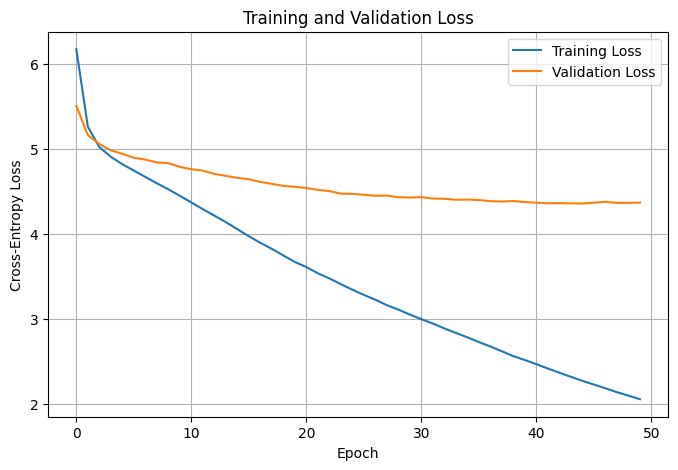

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [73]:
def indexes_to_words(indexes, index_to_word):
    words = []

    for idx in indexes:
        if idx in [SOS_token, EOS_token, PAD_token]:
            continue
        words.append(index_to_word.get(idx, "UNK"))

    return words

In [74]:
def evaluate_validation_metrics(encoder, decoder, val_loader, max_length=30, n_examples=5):

    encoder.eval()
    decoder.eval()

    correct_exact_matches = 0
    total_bleu_score = 0.0
    total_samples = 0

    smoothing = SmoothingFunction().method1

    print("\n--- Validation Examples ---")

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()


            encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(max_length):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()

            target_indices = target_tensor.cpu().tolist()
            input_indices = input_tensor.cpu().tolist()

            input_words = indexes_to_words(input_indices, index_to_french)
            target_words = indexes_to_words(target_indices, index_to_english)
            predicted_words = indexes_to_words(predicted_indices, index_to_english)

            if predicted_words == target_words:
                correct_exact_matches += 1

            bleu = sentence_bleu(
                [target_words],
                predicted_words,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoothing
            )

            total_bleu_score += bleu
            total_samples += 1

            if i < n_examples:
                print(f"Input:     {' '.join(input_words)}")
                print(f"Target:    {' '.join(target_words)}")
                print(f"Predicted: {' '.join(predicted_words)}")
                print(f"BLEU-4:    {bleu:.4f}")
                print("-" * 60)

    exact_accuracy = correct_exact_matches / total_samples
    avg_bleu = total_bleu_score / total_samples

    print("\nFinal Validation Metrics:")
    print(f"Traditional Exact-Match Accuracy: {exact_accuracy * 100:.2f}%")
    print(f"Average Validation BLEU-4 Score: {avg_bleu:.4f}")

    return exact_accuracy, avg_bleu

In [75]:
exact_accuracy, avg_bleu = evaluate_validation_metrics(
    encoder,
    decoder,
    val_loader
)


--- Validation Examples ---
Input:     elle a gagné un match de tennis
Target:    she won a tennis match
Predicted: she paints her lost a new pair of the ocean
BLEU-4:    0.0251
------------------------------------------------------------
Input:     le marché biologique ouvre à UNK le UNK
Target:    the organic market opens at UNK on UNK
Predicted: the birds are going to the party
BLEU-4:    0.0286
------------------------------------------------------------
Input:     nous regardons un film ensemble
Target:    we watch a movie together
Predicted: we are planning a new pair of the ocean
BLEU-4:    0.0285
------------------------------------------------------------
Input:     le pain de cette boulangerie est toujours UNK
Target:    the bread at this bakery is always UNK
Predicted: the birds are building a new pair of the ocean
BLEU-4:    0.0211
------------------------------------------------------------
Input:     nous UNK au mariage
Target:    we dance at the wedding
Predicted: we ar

In [76]:
def estimate_attn_flops(input_tensor, target_tensor, hidden_size, max_length):
    input_len = input_tensor.size(0)
    target_len = target_tensor.size(0)


    encoder_flops = input_len * (12 * hidden_size * hidden_size)


    attn_layer_flops = (hidden_size * max_length) + (2 * hidden_size * hidden_size) + (hidden_size * len(index_to_english))
    decoder_flops = target_len * (12 * hidden_size * hidden_size + attn_layer_flops)

    return encoder_flops + decoder_flops

In [77]:
def average_attn_flops(val_loader, hidden_size, max_length):
    total_flops = 0
    total_samples = 0

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0]
        target_tensor = target_tensor[0]

        total_flops += estimate_attn_flops(
            input_tensor,
            target_tensor,
            hidden_size,
            max_length
        )

        total_samples += 1

    return total_flops / total_samples

In [78]:
def evaluate_inference_speed(encoder, decoder, val_loader):
    start_time = time.time()
    num_batches = 0

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for input_tensor, target_tensor in val_loader:
            input_tensor = input_tensor[0].to(device)
            target_tensor = target_tensor[0].to(device)

            encoder_hidden = encoder.initHidden()
            encoder_outputs = torch.zeros(MAX_LENGTH, encoder.hidden_size, device=device)

            for ei in range(input_tensor.size(0)):
                encoder_output, encoder_hidden = encoder(
                    input_tensor[ei].unsqueeze(0),
                    encoder_hidden
                )
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            predicted_indices = []

            for di in range(MAX_LENGTH):
                decoder_output, decoder_hidden, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs
                )

                _, topi = decoder_output.topk(1)
                predicted_idx = topi.item()

                if predicted_idx == EOS_token:
                    break

                predicted_indices.append(predicted_idx)
                decoder_input = topi.detach()
            num_batches += 1

    end_time = time.time()
    total_inference_time_ms = (end_time - start_time) * 1000
    infer_ms_per_batch = total_inference_time_ms / num_batches

    return infer_ms_per_batch

In [79]:
attn_params = count_parameters(encoder) + count_parameters(decoder)
attn_flops = average_attn_flops(val_loader, hidden_size, MAX_LENGTH)
infer_ms_per_batch = evaluate_inference_speed(encoder, decoder, val_loader)

print(f"Attention Model Parameters: {attn_params:,}")
print(f"Attention Model Avg FLOPs per validation sample: {attn_flops:,.0f}")
print(f"Attention Model Inference Speed per batch (ms): {infer_ms_per_batch:.2f}")

Attention Model Parameters: 1,641,357
Attention Model Avg FLOPs per validation sample: 14,181,738
Attention Model Inference Speed per batch (ms): 8.32


In [80]:
def evaluate_and_show_attention(encoder, decoder, sentence, max_length=MAX_LENGTH):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        input_tensor = train_dataset.sentence_to_tensor(sentence, french_to_index)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.initHidden()

        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei].unsqueeze(0),
                encoder_hidden
            )
            encoder_outputs[ei] = encoder_output[0, 0]

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []
        attentions = torch.zeros(max_length, max_length)

        for di in range(max_length):
            decoder_output, decoder_hidden, attn_weights = decoder(
                decoder_input,
                decoder_hidden,
                encoder_outputs
            )
            attentions[di] = attn_weights.data
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(index_to_english[topi.item()])

            decoder_input = topi.squeeze().detach()

        return decoded_words, attentions[:di + 1, :input_length]

def show_attention_heatmap(input_sentence, output_words, attentions):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel('Input French Sentence')
    plt.ylabel('Predicted English Sentence')
    plt.title('Attention Weights (French to English)')
    plt.show()



--- Attention Visualization Examples ---

Input French: elle a gagné un match de tennis
Predicted English: she paints her lost a new pair of the ocean <EOS>


/tmp/ipykernel_14107/399176109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/399176109.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


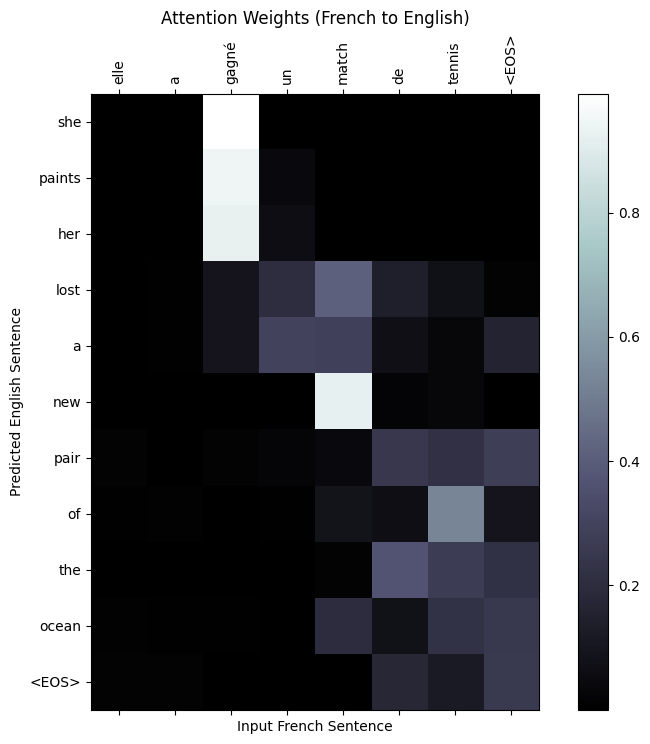


Input French: le marché biologique ouvre à UNK le UNK
Predicted English: the birds are going to the party <EOS>


/tmp/ipykernel_14107/399176109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/399176109.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


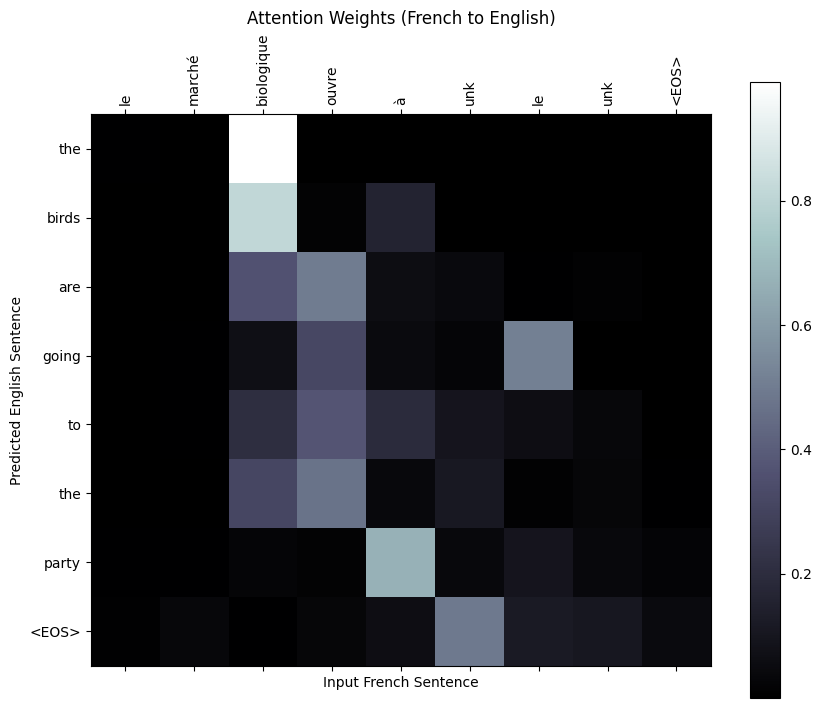


Input French: nous regardons un film ensemble
Predicted English: we are planning a new pair of the ocean <EOS>


/tmp/ipykernel_14107/399176109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/399176109.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


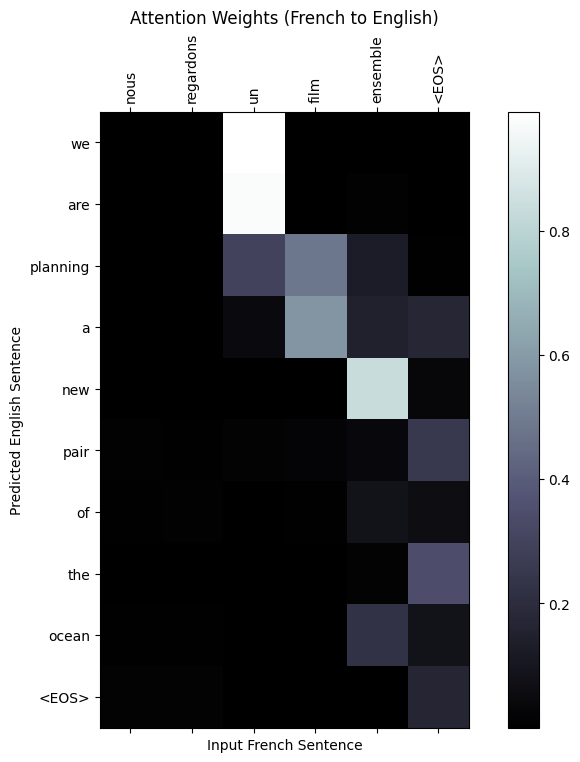


Input French: le pain de cette boulangerie est toujours UNK
Predicted English: the birds are building a new pair of the ocean <EOS>


/tmp/ipykernel_14107/399176109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/399176109.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


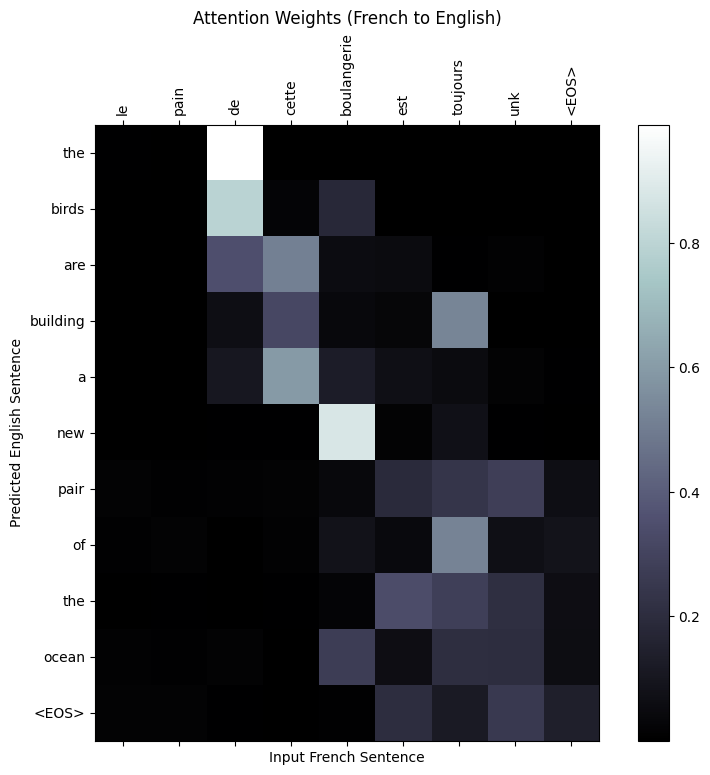


Input French: nous UNK au mariage
Predicted English: we are going to the beach <EOS>


/tmp/ipykernel_14107/399176109.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + split_word(input_sentence) + ['<EOS>'], rotation=90)
/tmp/ipykernel_14107/399176109.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


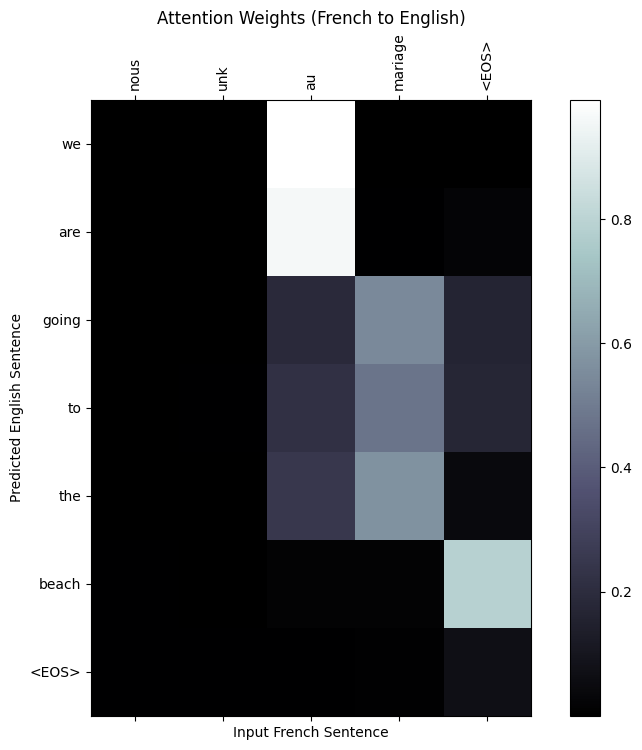

In [82]:
import matplotlib.ticker as ticker


num_examples_to_show = 5

print("\n--- Attention Visualization Examples ---")
for i, (input_tensor, target_tensor) in enumerate(val_loader):
    if i >= num_examples_to_show:
        break

    # The input to this model is French (french_to_index)
    input_indices = input_tensor[0].cpu().tolist()
    input_words = indexes_to_words(input_indices, index_to_french)
    input_sentence_fr = ' '.join(input_words)

    output_words, attentions = evaluate_and_show_attention(encoder, decoder, input_sentence_fr)

    print(f"\nInput French: {input_sentence_fr}")
    print(f"Predicted English: {' '.join(output_words)}")
    show_attention_heatmap(input_sentence_fr, output_words, attentions)